In [4]:
import torch
import matplotlib.pyplot as plt

import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassAccuracy
from tqdm.auto import tqdm

/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
train_data = datasets.FashionMNIST(
    root = "data",
    transform = transforms.ToTensor(),
    download = True,
    train = True,
    target_transform = None
)

In [6]:
test_data = datasets.FashionMNIST(
    root = "data",
    transform = transforms.ToTensor(),
    download = True,
    train = False,
    target_transform = None
)

In [7]:
image, label = train_data[0]

In [8]:
image.shape

torch.Size([1, 28, 28])

In [9]:
label

9

In [10]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [11]:
class_names = train_data.classes
class_names[label]

'Ankle boot'

In [12]:
len(train_data)

60000

In [1]:
# plt.imshow(image.squeeze(), cmap="grey")
# plt.axis(False)
# plt.title(class_names[label])

In [2]:
# rows = 4
# cols = 4

# torch.manual_seed(42)

# fig = plt.figure(figsize=(12, 13))
# for i in range(1, rows * cols + 1):
#     image_idx = torch.randint(0, len(train_data), (1,)).item()
#     image, label = train_data[image_idx]
#     fig.add_subplot(rows, cols, i)
#     plt.imshow(image.squeeze())
#     plt.title(class_names[label])

In [13]:
train_loader = DataLoader(
    train_data, batch_size = 32, shuffle = True
)

test_loader = DataLoader(
    test_data, batch_size = 32, shuffle = True
)

In [14]:
len(train_loader), test_loader

(1875, <torch.utils.data.dataloader.DataLoader at 0x117dd2350>)

In [15]:
train_features, train_label = next(iter(train_loader))
len(train_features), len(train_label)

(32, 32)

In [16]:
train_features.shape, train_label.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [17]:
train_features.shape, train_label.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [18]:
train_features[1].shape, train_label[1].squeeze().item()

(torch.Size([1, 28, 28]), 8)

Text(0.5, 1.0, 'Dress')

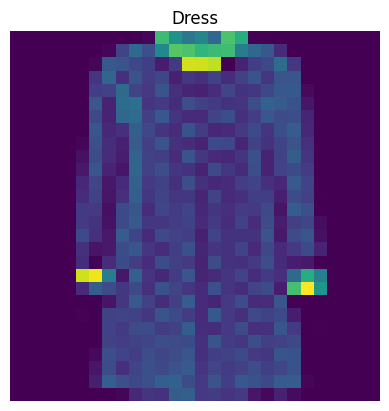

In [19]:
img = train_features[16]

plt.imshow(img.squeeze())
plt.axis("off")
plt.title(class_names[train_label[16].item()])

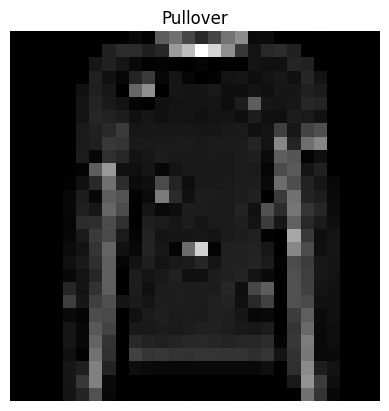

In [20]:
for i in range(1, len(train_features)):
    rand_idx = torch.randint(0, len(train_features), size = (1,)).item()
    img, label = train_features[rand_idx], train_label[rand_idx]
    plt.imshow(img.squeeze(), cmap="grey")
    plt.title(class_names[label])
    plt.axis(False)

In [21]:
train_label.unique().squeeze()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [22]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [173]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self, input_features: int = None, output_features: int = None, hidden_units: int = 10):
        super(FashionMNISTModel, self).__init__()
        
        self.network = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(
                in_features = input_features, out_features = hidden_units
            ),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(
                in_features = hidden_units, out_features = 64
            ),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(
                in_features = 64, out_features = output_features
            )
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [174]:
train_features.shape

torch.Size([32, 1, 28, 28])

In [175]:
torch.manual_seed(42)

In [176]:
model = FashionMNISTModel(input_features = 784, output_features = len(class_names), hidden_units = 128).to(device)
# model.to(device)
model

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [177]:
from timeit import default_timer as timer

def calculate_training_time(start: float, end: float, device: torch.device = "cpu"):
    time_taken = end - start
    print(f"Time Taken : {time_taken:.3f}, on Device: {device}")
    return

In [178]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
accuracy_fn = MulticlassAccuracy(num_classes = 10).to(device)

In [186]:
epochs = 10
total_epochs = []
losses = []
test_losses = []
total_train_accuracy = []
total_test_accuracy = []

start = timer()

for epoch in tqdm(range(epochs)):
    running_loss = 0.0
    running_acc = 0.0
    running_test_loss = 0.0
    running_test_acc = 0.0
    
    model.train()

    for idx, (image, target) in enumerate(train_loader):
        image, target = image.to(device), target.to(device)
        target_pred_logits = model(image)
        # target_pred = torch.argmax(target_pred_logits, dim = 1)
        # train_accuracy = accuracy_fn(target, target_pred)

        loss = loss_fn(target_pred_logits, target)
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        target_pred = torch.argmax(target_pred_logits, dim = 1)
        train_accuracy = accuracy_fn(target, target_pred)
        running_loss += loss
        running_acc += train_accuracy

        # losses.append(loss.item())
        # total_train_accuracy.append(train_accuracy.item())

    avg_loss = running_loss / len(train_loader)
    avg_acc = running_acc / len(train_loader)
    losses.append(loss.item())
    total_train_accuracy.append(train_accuracy.item())

    model.eval()
    
    with torch.inference_mode():
        for idx, (image, target) in enumerate(test_loader):
            image, target = image.to(device), target.to(device)
            test_pred_logits = model(image)
    
            test_loss = loss_fn(test_pred_logits, target)
            test_pred = torch.argmax(test_pred_logits, dim = 1)
            test_accuracy = accuracy_fn(target, test_pred)
    
            running_test_loss += test_loss
            running_test_acc += test_accuracy

        avg_test_loss = running_test_loss / len(test_loader)
        avg_test_acc = running_test_acc / len(test_loader)
        test_losses.append(test_loss.item())
        total_test_accuracy.append(test_accuracy.item())

    # if idx % (0.1 * len(train_loader)) == 0:
    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Traning Loss: {avg_loss} | Accuracy: {avg_acc}")
        print(f"Testing Loss: {avg_test_loss} | Accuracy: {avg_test_acc}\n")

end = timer()
calculate_training_time(start, end, device)

 10%|████▍                                       | 1/10 [00:25<03:51, 25.69s/it]

Traning Loss: 0.19517318904399872 | Accuracy: 0.9192015528678894
Testing Loss: 0.3567919135093689 | Accuracy: 0.8783736824989319



 20%|████████▊                                   | 2/10 [00:51<03:27, 25.91s/it]

Traning Loss: 0.19187957048416138 | Accuracy: 0.9197857975959778
Testing Loss: 0.34485864639282227 | Accuracy: 0.8784575462341309



 30%|█████████████▏                              | 3/10 [01:17<03:02, 26.02s/it]

...

Traning Loss: 0.18141232430934906 | Accuracy: 0.9238923788070679
Testing Loss: 0.36240723729133606 | Accuracy: 0.8760465383529663



 90%|███████████████████████████████████████▌    | 9/10 [03:52<00:25, 25.77s/it]

Traning Loss: 0.18373344838619232 | Accuracy: 0.9229869246482849
Testing Loss: 0.3779829144477844 | Accuracy: 0.8743456602096558



100%|███████████████████████████████████████████| 10/10 [04:18<00:00, 25.85s/it]

Traning Loss: 0.18173865973949432 | Accuracy: 0.9234355688095093
Testing Loss: 0.34140825271606445 | Accuracy: 0.8793573975563049

Time Taken : 258.516, on Device: mps


Text(0.5, 1.0, 'True Label: Dress | Model Prediction: Dress')

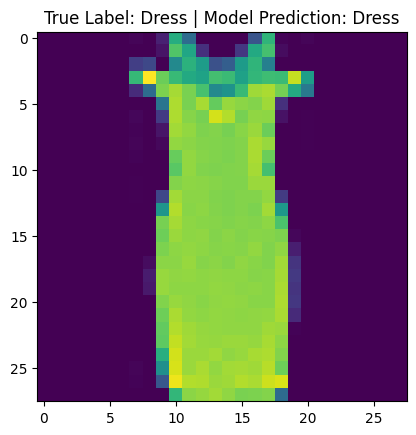

In [180]:
torch.manual_seed(42)

model.eval()
test_features, test_label = next(iter(test_loader))

single_img = test_features[0].unsqueeze(dim = 1).to(device)

with torch.inference_mode():
    target_logits = model(single_img)
    target_pred = torch.argmax(target_logits, dim = 1)


# class_names[target_pred], class_names[test_label[0]]

plt.imshow(test_features[0].squeeze())
plt.title(f"True Label: {class_names[test_label[0]]} | Model Prediction: {class_names[target_pred]}")

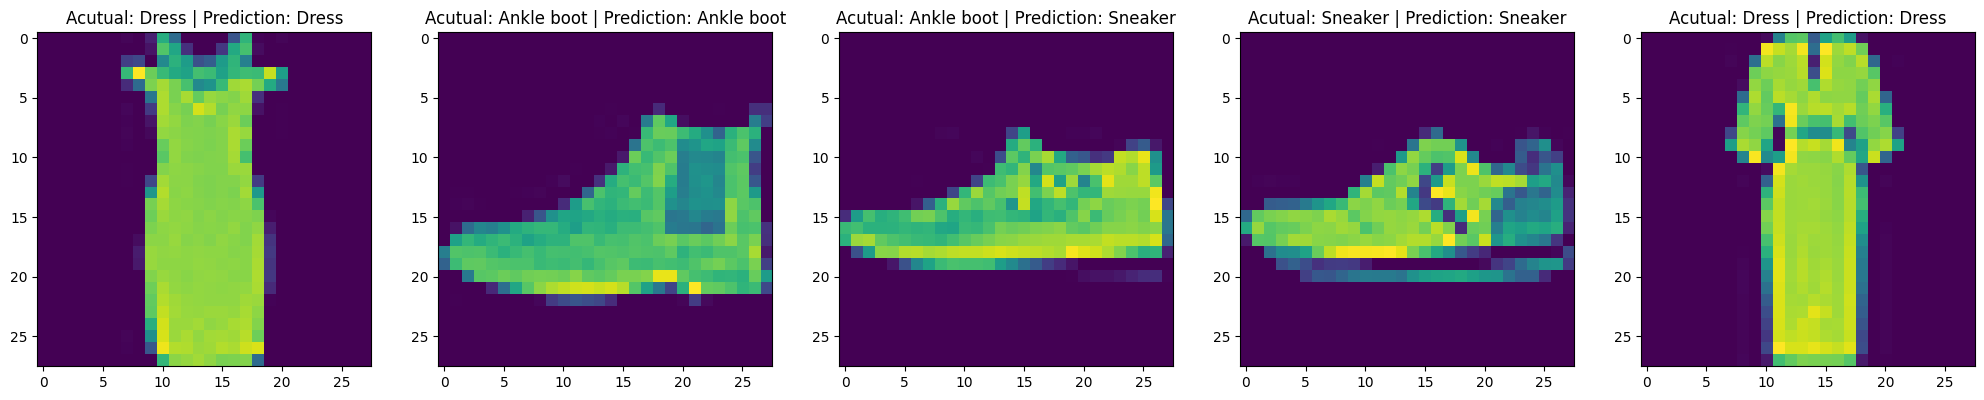

In [181]:
# model.eval()

torch.manual_seed(42)
torch.mps.manual_seed(42)

test_classes_names = test_data.classes
model.eval()
features, targets = next(iter(test_loader))

with torch.inference_mode():
    y_pred = torch.argmax(model(features.to(device)).detach().cpu(), dim = 1)

plt.figure(figsize=(25, 20))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(features[i].squeeze())
    plt.title(f"Acutual: {test_classes_names[targets[i]]} | Prediction: {test_classes_names[y_pred[i]]}")
    plt.axis("on")
# for i in range(1, 10):
#     plt.subplot(1, 10, i+1)
#     plt.imshow(y_pred)

# with torch.inference_mode
# test_classes_names
# model.eval()
# with torch.inference_mode():
#     for idx, (feature, target) in enumerate(test_loader):
#         feature, target = feature.to(device), target.to(device)
#         target_logits = model(feature)

#         target_pred = torch.argmax(target_logits, dim = 1)

# plt.imshow(target_logits.detach().cpu().unsqueeze(0))
# target_logits.unsqueeze(0).shape

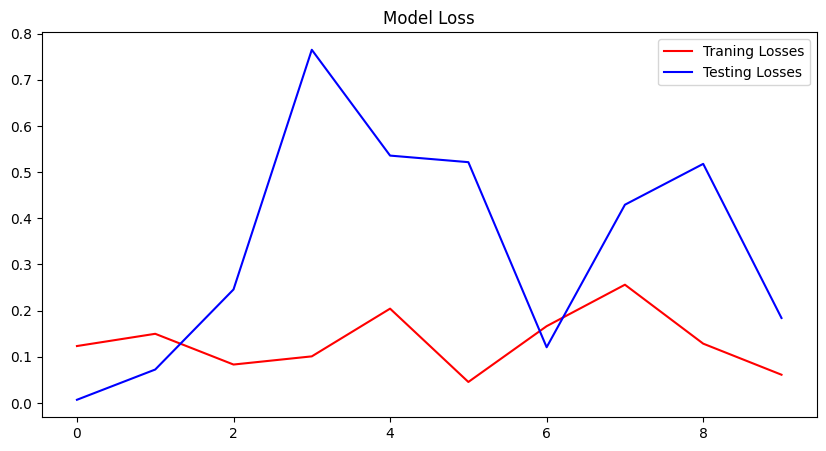

In [187]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, losses, label = "Traning Losses", c = "red")
plt.plot(total_epochs, test_losses, label = "Testing Losses", c = "blue")
plt.title("Model Loss")
plt.legend()
plt.show()

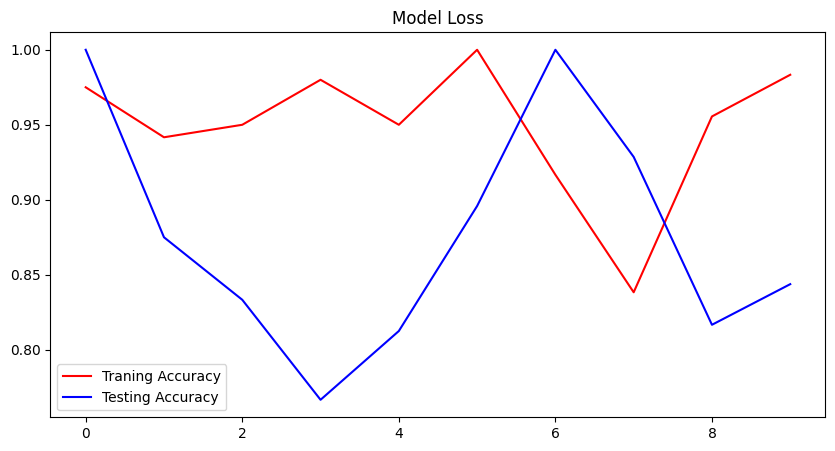

In [189]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, total_train_accuracy, label = "Traning Accuracy", c = "red")
plt.plot(total_epochs, total_test_accuracy, label = "Testing Accuracy", c = "blue")
plt.title("Model Loss")
plt.legend()
plt.show()

In [193]:
total_test_accuracy, len(total_test_accuracy)

([1.0,
  0.875,
  0.8333333730697632,
  0.7666666507720947,
  0.8125,
  0.8958333730697632,
  1.0,
  0.9285714626312256,
  0.8166667222976685,
  0.84375],
 10)